tutaj koncentrujemy się głównie na analizie jedno- i wielowymiarowej wybranych zmiennych, ale także część analiz możemy podciągnąć pod ogólną analize cen (można to potraktować jako motywacja do konstrukcji zmiennych w poprzednim skrypcie)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import math
import folium

import rasterio
from rasterio.transform import rowcol
from rasterio.merge import merge
from rasterio.mask import mask
from pyproj import Transformer

import osmium

from sklearn.neighbors import BallTree
from tqdm import tqdm
import time

from sklearn.cluster import DBSCAN

from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.preprocessing import RobustScaler
from branca.colormap import linear

from ydata_profiling import ProfileReport

In [2]:
# DEFINICJE #

# MAPY #
france_regions_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/regions.geojson" 
france_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements-version-simplifiee.geojson" 

# TRZCIONKA NA WYKRESACH #
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5})

0. PRÓBKOWANIE

In [3]:
data = pd.read_csv("D:\\nieruchomosci_ostateczne\\samples\\sample4_enhanced.txt")

# WAŻNE: jak tworzymy próbki to bierzemy po 1 rekordzie dla transakcji wielo obiektowych i te zawierające mieszkanie/dom (w praktyce pierwszy filtr powinien starczyć) #
data = data[data["local_type"].isin(["Apartment", "House"])]
data = data.drop_duplicates('transaction_id')


data['department_code'] = data.department_code.astype(str)

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)
ids_houses = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\houses_transaction_ids.txt", dtype=str)
ids_apartments = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\apartments_transaction_ids.txt", dtype=str)

all_ids = set(ids1) | set(ids2) | set(ids3)
apartment_ids = set(ids1) | set(ids2) 

sample_one_apartment = data[data.transaction_id.isin(ids1)]
sample_one_apartment_one_outbuilding = data[data.transaction_id.isin(ids2)]
#sample_apartments = data[data.transaction_id.isin(ids_apartments)]

#sample_one_house = data[data.transaction_id.isin(ids3)]
#sample_houses = data[data.transaction_id.isin(ids_houses)]

sample_one_apartment_paris = sample_one_apartment[sample_one_apartment.department_code.isin(['75', '92', '93', '94'])]
#sample_apartments_paris = sample_apartments[sample_apartments.department_code.isin(['75', '92', '93', '94'])]


# samples = {
#     "one_apartment": sample_one_apartment,
#     "one_apartment_one_outbuilding": sample_one_apartment_one_outbuilding,
#     "one_house": sample_one_house,
#     "apartments": sample_apartments,
#     'houses': sample_houses,
#     "one_apartment_paris": sample_one_apartment_paris,
#     "apartments_paris": sample_apartments_paris
# }

C:\Users\jpiec\AppData\Local\Temp\ipykernel_12852\4127838788.py:1: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("D:\\nieruchomosci_ostateczne\\samples\\sample4_enhanced.txt")


In [4]:
CHOICE = 4

if CHOICE == 2:
    sample = sample_one_apartment
    key = 'sample_one_apartment'
elif CHOICE == 2:
    sample = sample_one_apartment_one_outbuilding
    key = 'sample_one_apartment_one_outbuilding'
elif CHOICE == 3:
    sample = sample_one_house
elif CHOICE == 4:
    sample = sample_one_apartment_paris
    key = 'sample_one_apartment_paris'

# elif CHOICE == -1:
#     sample = data[data.transaction_id.isin(ids_houses)]
elif CHOICE == -2:
    sample = data[data.transaction_id.isin(ids_apartments)]

In [5]:
num_features = ['number_of_rooms', 'longitude', 'latitude', 'full_built_surface', 'population_density', 'log_population_density', 
       'n_factors_shop_100', 'n_factors_shop_500', 'n_factors_shop_1000', 'n_factors_amenity_100', 'n_factors_amenity_500', 'n_factors_amenity_1000',
       'n_factors_healthcare_100', 'n_factors_healthcare_500', 'n_factors_healthcare_1000', 'n_factors_airport_100', 'n_factors_airport_500', 
       'n_factors_airport_1000', 'n_factors_natural_100', 'n_factors_natural_500', 'n_factors_natural_1000', 'n_factors_public_transport_100',
       'n_factors_public_transport_500', 'n_factors_public_transport_1000', 'n_factors_all_100', 'n_factors_all_500', 'n_factors_all_1000',
       'closest_hospital_dist_m', 'closest_hospital_EXACT_dist_m', 'closest_school_dist_m', 'closest_school_EXACT_dist_m','closest_transport_dist_m', 
       'closest_transport_EXACT_dist_m', 'closest_shop_dist_m', 'closest_shop_EXACT_dist_m', 'closest_airport_dist_m', 
       'dist_to_big_city_km', 'min_border_dist_km', 'within_1km_border', 'within_5km_border', 'within_20km_border', 'within_5km_city', 'within_10km_city', 'within_20km_city', 
       'avg_building_age', 'avg_building_floor', 'dpe_a', 'dpe_b', 'dpe_c', 'dpe_d', 'dpe_e', 'dpe_f', 'dpe_g']

cat_features = ['commune_code', 'department_code', 'nearest_big_city', 'border']

targ = ['price_m_2']

ydata-profiling

In [6]:
subset = sample[num_features + cat_features + targ].copy()

profile = ProfileReport(subset, title="Profiling Report", correlations={"auto": {"calculate": False}, "pearson": {"calculate": True}, "spearman": {"calculate": True}})

profile.to_file(f"{key}_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 58/58 [00:06<00:00,  8.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

1. ANALIZA TARGETU

dane wybuchające do inf: 0


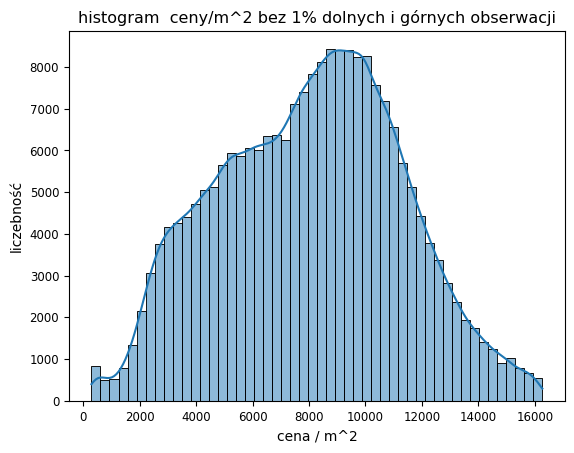

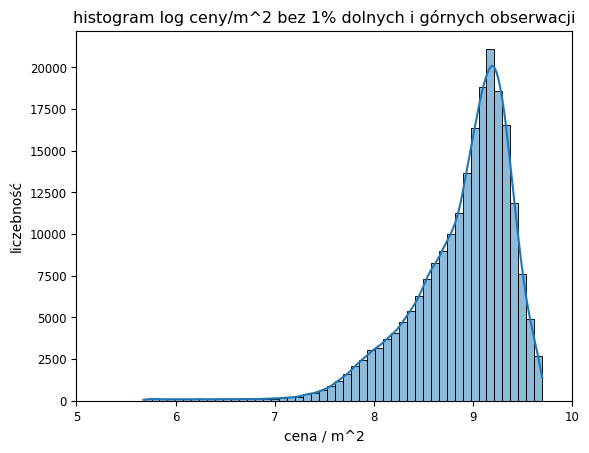

In [41]:
# liczba błędnych cen
print(f'dane wybuchające do inf: {len(sample) - np.isfinite(sample.price_m_2).sum()}')

# wykres 1

target = sample['price_m_2']
target = target[(target < target.quantile(0.98)) & (target > target.quantile(0.02))]  

sns.histplot(target, bins=50, kde=True)
plt.title("histogram  ceny/m^2 bez 1% dolnych i górnych obserwacji")
plt.xlabel("cena / m^2")
plt.ylabel("liczebność")
plt.show()

# wykres 2

target_log = np.log(target)

sns.histplot(target_log, bins=50, kde=True)
plt.title("histogram log ceny/m^2 bez 1% dolnych i górnych obserwacji")
plt.xlabel("cena / m^2")
plt.xlim((5,10))
plt.ylabel("liczebność")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


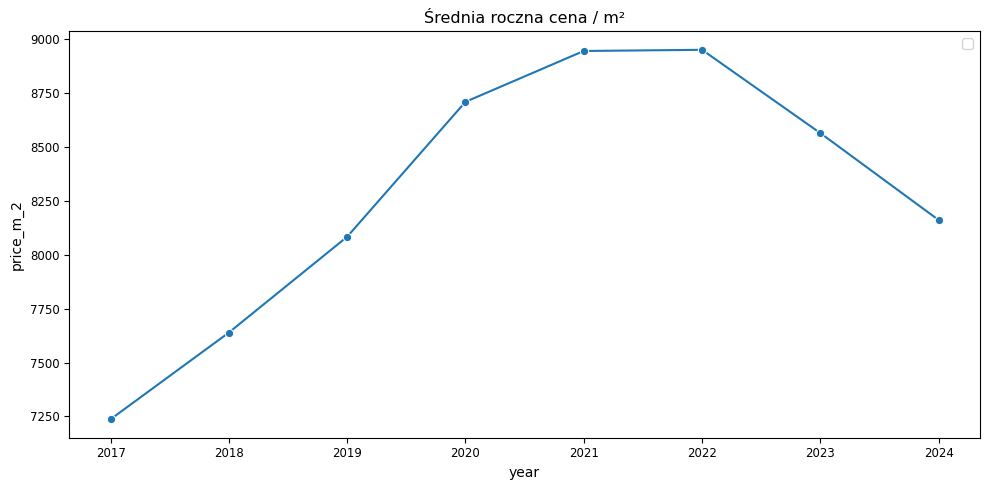

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


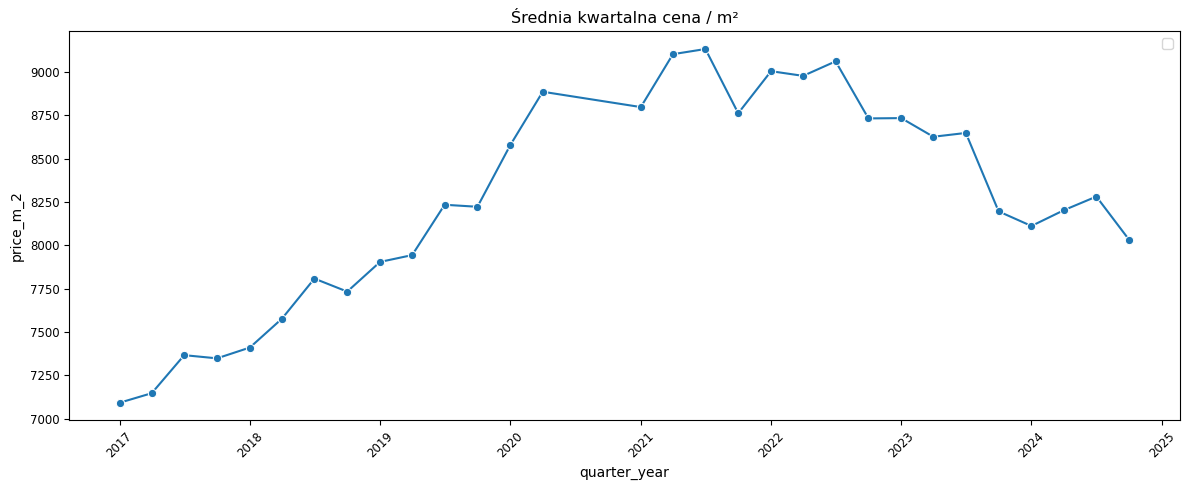

In [23]:
sample = sample.copy()

plt.figure(figsize=(10, 5))


avg_per_year = sample.groupby("year")["price_m_2"].mean().reset_index().sort_values("year")
sns.lineplot(data=avg_per_year, x="year", y="price_m_2", marker="o")

plt.title("Średnia roczna cena / m²")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))


sample["transaction_date"] = pd.to_datetime(sample["transaction_date"])
sample["quarter_year"] = sample["transaction_date"].dt.to_period("Q")
    
avg_per_quarter = sample.groupby("quarter_year")["price_m_2"].mean().reset_index().sort_values("quarter_year")
avg_per_quarter["quarter_year"] = avg_per_quarter["quarter_year"].dt.to_timestamp()

sns.lineplot(data=avg_per_quarter, x="quarter_year", y="price_m_2", marker="o")

plt.title("Średnia kwartalna cena / m²")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
sample = sample[(sample.price_m_2 > sample.price_m_2.quantile(0.02)) & (sample.price_m_2 < sample.price_m_2.quantile(0.98))].copy()
sample["log_price_m_2"] = np.log(sample.price_m_2)

In [ ]:
# plt.figure(figsize=(10, 5))

# for name, df in samples.items():

#     avg_per_year = df.groupby("year")["property_value"].mean().reset_index().sort_values("year")
#     sns.lineplot(data=avg_per_year, x="year", y="property_value", marker="o", label=name)

# plt.title("Średnia roczna cena / m²")
# plt.legend()
# plt.tight_layout()
# plt.show()


# plt.figure(figsize=(12, 5))

# for name, df in samples.items():
    
#     df["transaction_date"] = pd.to_datetime(df["transaction_date"])
#     df["quarter_year"] = df["transaction_date"].dt.to_period("Q")
    
#     avg_per_quarter = df.groupby("quarter_year")["property_value"].mean().reset_index().sort_values("quarter_year")
#     avg_per_quarter["quarter_year"] = avg_per_quarter["quarter_year"].dt.to_timestamp()

#     sns.lineplot(data=avg_per_quarter, x="quarter_year", y="property_value", marker="o", label=name)

# plt.title("Średnia kwartalna cena / m²")
# plt.xticks(rotation=45)
# plt.legend()
# plt.tight_layout()
# plt.show()

2. cena za metr kwadratowy w podziale na departamenty/regiony

In [24]:
if CHOICE != 4:

    sample_department = sample.groupby('department_code').price_m_2.mean().reset_index(name='avg_price_m_2_adj')

    fr_map = gpd.read_file(france_departments_map_url)
    fr_map = fr_map.merge(sample_department, how = 'left', left_on='code', right_on='department_code')

    fig, ax = plt.subplots(figsize=(8, 8))
    fr_map.plot(column="avg_price_m_2_adj", ax=ax, cmap="viridis", legend=True,  missing_kwds={"color": "lightgrey", "label": "brak danych"},  edgecolor="black", linewidth=0.3,  legend_kwds={"shrink": 0.6, "label": "€/m²"})

    ax.set_title("Średnia cena za m² (skorygowana HPI) w departamentach Francji")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
if CHOICE == 4:
    pass

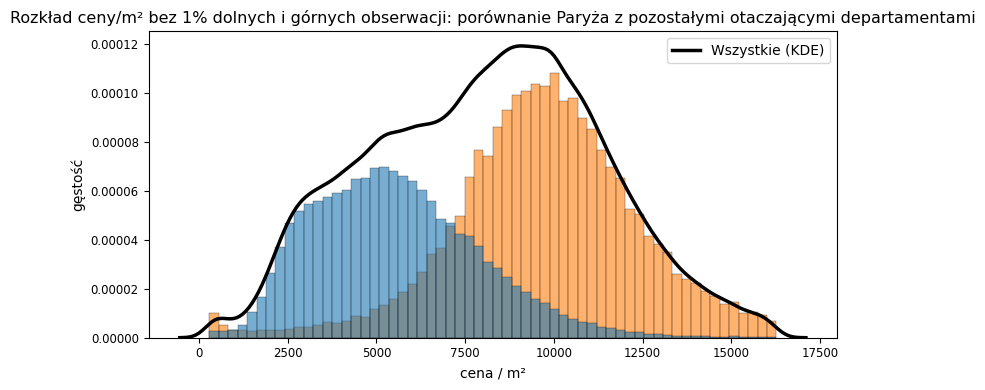

In [44]:
# PRZYKŁAD: dlaczego rozkład 2-modalny dla mieszań ? Chodzi o Paryż I np. miasta na Lazurowym Wybrzeżu, gdzie ceny są wyższe #

coastal_communes_06 = ["06088", "06157", "06123", "06027", "06149", "06030", "06155", "06159", "06152"]

df_rich_cities  = sample[(sample.department_code == '75') | (sample.postal_code.isin(coastal_communes_06))]
df_rest = sample[~((sample.department_code == '75') | (sample.postal_code.isin(coastal_communes_06)))]

df_plot = sample.copy()
df_plot["group"] = "Reszta Francji"
df_plot.loc[df_plot.index.isin(df_rich_cities.index), "group"] = "Paryż + inne drogie miasta"

plt.figure(figsize=(8,4))

sns.histplot(data=df_plot, x="price_m_2", hue="group", bins=60, stat="density", common_norm=True, multiple="layer", alpha=0.6, edgecolor="black", linewidth=0.2)
sns.kdeplot(data=df_plot, x="price_m_2", color="black", lw=2.5, label="Wszystkie (KDE)")

plt.title("Rozkład ceny/m² bez 1% dolnych i górnych obserwacji: porównanie Paryża z pozostałymi otaczającymi departamentami")
plt.xlabel("cena / m²")
plt.ylabel("gęstość")
plt.legend()
plt.tight_layout()
plt.show()

usuwamy 1% dolnych i górnych outlierów i transformujemy target o logarytm

3. ANALIZA `number_of_rooms` i `built_surface`

In [11]:
sample.full_built_surface.quantile([0.01, 0.95, 0.98, 0.99])

0.01      9.0
0.95     96.0
0.98    125.0
0.99    150.0
Name: full_built_surface, dtype: float64

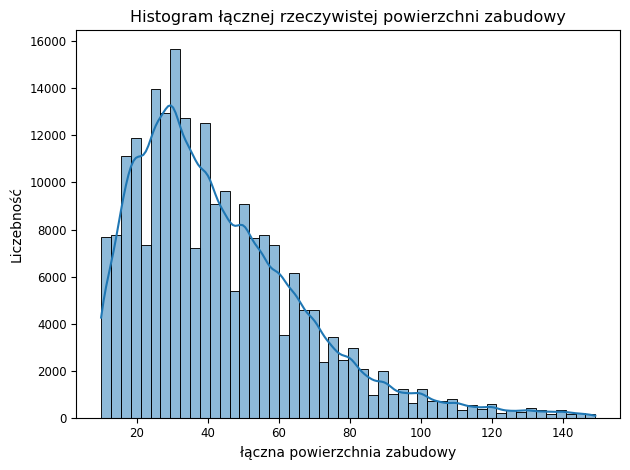

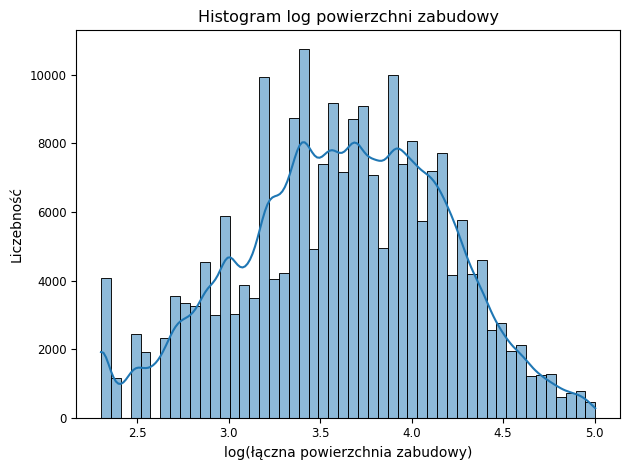

In [12]:
sns.histplot(x=sample.loc[sample.full_built_surface < sample.full_built_surface.quantile(0.99), "full_built_surface"].clip(lower=10), bins=50, kde=True)

plt.title("Histogram łącznej rzeczywistej powierzchni zabudowy")
plt.xlabel("łączna powierzchnia zabudowy")
plt.ylabel("Liczebność")
plt.tight_layout()
plt.show()



sns.histplot(x=np.log(sample.loc[sample.full_built_surface < sample.full_built_surface.quantile(0.99), "full_built_surface"].clip(lower=10)), bins=50, kde=True)

plt.title("Histogram log powierzchni zabudowy")
plt.xlabel("log(łączna powierzchnia zabudowy)")
plt.ylabel("Liczebność")
plt.tight_layout()
plt.show()

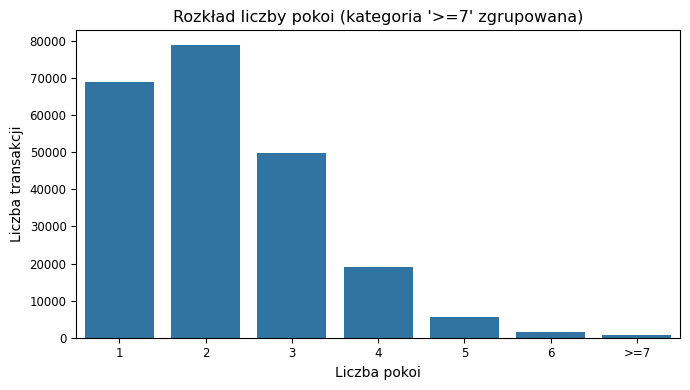

In [13]:
rooms = pd.to_numeric(sample["number_of_rooms"], errors="coerce").dropna()
rooms_cat = rooms.clip(upper=7).replace({7: ">=7"})
counts = rooms_cat.value_counts()
order = [1, 2, 3, 4, 5, 6, ">=7"]
subset = counts.reindex(order, fill_value=0).reset_index()
subset.columns = ["number_of_rooms", "freq"]

plt.figure(figsize=(7, 4))
sns.barplot(data=subset, x="number_of_rooms", y="freq", order=order)
plt.title("Rozkład liczby pokoi (kategoria '>=7' zgrupowana)")
plt.xlabel("Liczba pokoi")
plt.ylabel("Liczba transakcji")
plt.tight_layout()
plt.show()

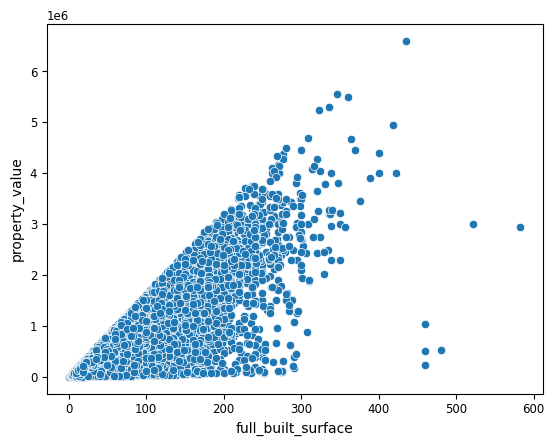

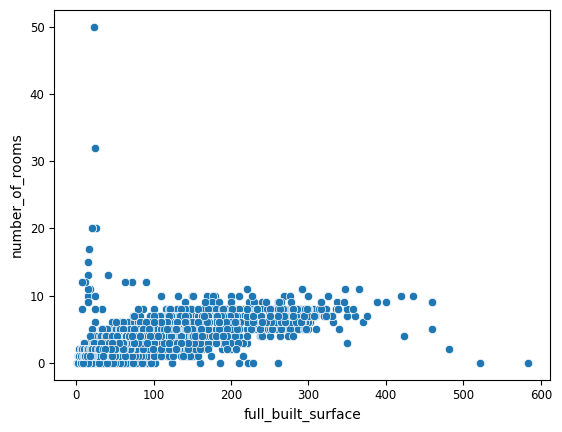

In [45]:
#sns.scatterplot(x='number_of_rooms', y='full_built_surface', data=sample)

sns.scatterplot(x='full_built_surface', y='property_value', data=sample)
plt.show()

sns.scatterplot(x ='full_built_surface', y='number_of_rooms', data = sample)
plt.show()

In [46]:
sample = sample.copy()

q99_surface = sample["full_built_surface"].quantile(0.99)

sample.loc[:, "full_built_surface"] = sample["full_built_surface"].clip(lower=10, upper=q99_surface)
sample.loc[:, "number_of_rooms"] = sample["number_of_rooms"].clip(upper=7)

4. POZOSTAŁE ZMIENNE

In [47]:
# Usuwamy zmienne związane z lotniskami - za niska wariancja
sample = sample.drop(columns = ['n_factors_airport_100', 'n_factors_airport_500', 'n_factors_airport_1000'])

5. ANALIZA WIELOWYMIAROWA - MACIERZ KORELACJI

In [56]:
sample.columns

Index(['transaction_id', 'transaction_date', 'disposition_number',
       'transaction_type', 'property_value', 'postal_code', 'commune_code',
       'commune_name', 'department_code', 'parcel_id', 'local_type',
       'built_surface', 'number_of_rooms', 'land_use', 'land_area',
       'longitude', 'latitude', 'month_year', 'month', 'year', 'quarter',
       'full_built_surface', 'price_m_2', 'population_density',
       'log_population_density', 'n_factors_shop_100', 'n_factors_shop_500',
       'n_factors_shop_1000', 'n_factors_amenity_100', 'n_factors_amenity_500',
       'n_factors_amenity_1000', 'n_factors_healthcare_100',
       'n_factors_healthcare_500', 'n_factors_healthcare_1000',
       'n_factors_natural_100', 'n_factors_natural_500',
       'n_factors_natural_1000', 'n_factors_public_transport_100',
       'n_factors_public_transport_500', 'n_factors_public_transport_1000',
       'n_factors_all_100', 'n_factors_all_500', 'n_factors_all_1000',
       'closest_hospital_dist

In [57]:
num_features = ['number_of_rooms', 'longitude', 'latitude', 'full_built_surface', 'population_density', 'log_population_density', 
       'n_factors_shop_100', 'n_factors_shop_500', 'n_factors_shop_1000', 'n_factors_amenity_100', 'n_factors_amenity_500', 'n_factors_amenity_1000',
       'n_factors_healthcare_100', 'n_factors_healthcare_500', 'n_factors_healthcare_1000', 'n_factors_natural_100', 'n_factors_natural_500', 'n_factors_natural_1000', 'n_factors_public_transport_100',
       'n_factors_public_transport_500', 'n_factors_public_transport_1000', 'n_factors_all_100', 'n_factors_all_500', 'n_factors_all_1000',
       'closest_hospital_dist_m', 'closest_hospital_EXACT_dist_m', 'closest_school_dist_m', 'closest_school_EXACT_dist_m','closest_transport_dist_m', 
       'closest_transport_EXACT_dist_m', 'closest_shop_dist_m', 'closest_shop_EXACT_dist_m', 'closest_airport_dist_m', 
       'dist_to_big_city_km', 'min_border_dist_km', 'within_1km_border', 'within_5km_border', 'within_20km_border', 'within_5km_city', 'within_10km_city', 'within_20km_city', 
       'avg_building_age', 'avg_building_floor', 'dpe_a', 'dpe_b', 'dpe_c', 'dpe_d', 'dpe_e', 'dpe_f', 'dpe_g']

cat_features = ['commune_code', 'department_code', 'nearest_big_city', 'border']

targ = ['price_m_2']

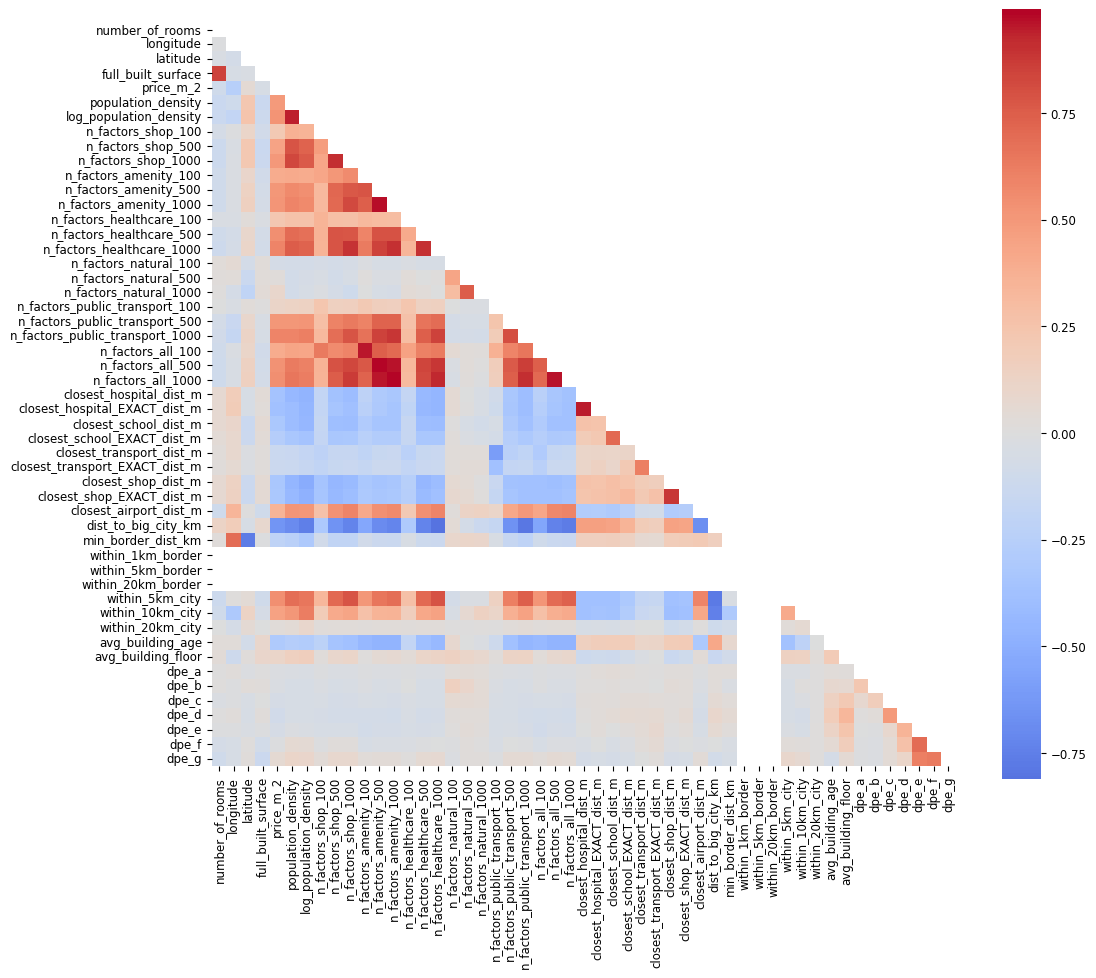

In [60]:
corr = sample.loc[:, sample.columns.isin(num_features + targ)].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True)
plt.show()

3. REPREZENTATYWNOŚĆ DANYCH

stabilność próbki w czasie

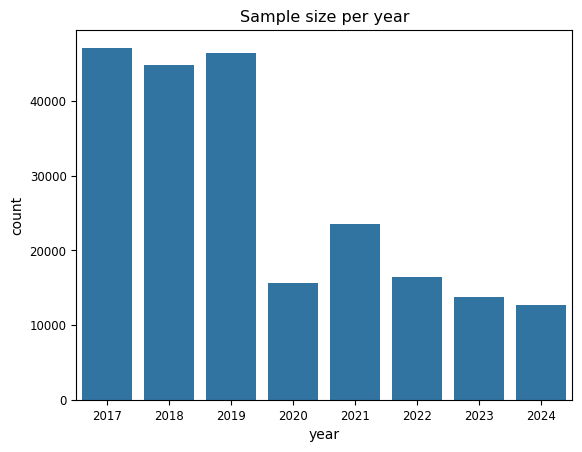

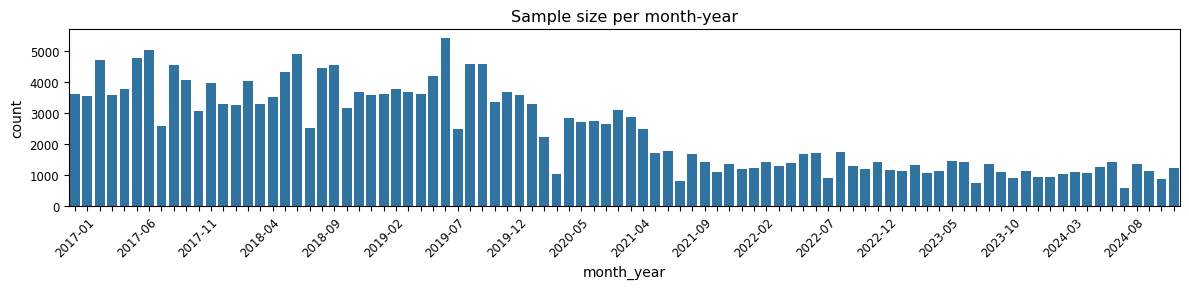

In [53]:
size_per_year = sample.groupby('year').size().reset_index(name="count")

sns.barplot(data = size_per_year, x="year", y="count")
plt.title("Sample size per year")
plt.show()


size_per_month = sample.groupby('month_year').size().reset_index(name='count')
#size_per_month2 = sample_apartments_paris.groupby('month_year').size().reset_index(name='count')

size_per_month['month_year'] = size_per_month['month_year'].astype(str)
#size_per_month2['month_year'] = size_per_month2['month_year'].astype(str)

order = size_per_month["month_year"]  # wspólna kolejność osi

fig, ax = plt.subplots(figsize=(12,3))

sns.barplot(data=size_per_month, x="month_year", y="count", ax=ax, order=order, color="tab:blue")
#sns.barplot(data=size_per_month2, x="month_year", y="count", ax=ax, order=order, color="tab:red", alpha=0.4)

for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

ax.set_title('Sample size per month-year')
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

stabilność w przestrzeni

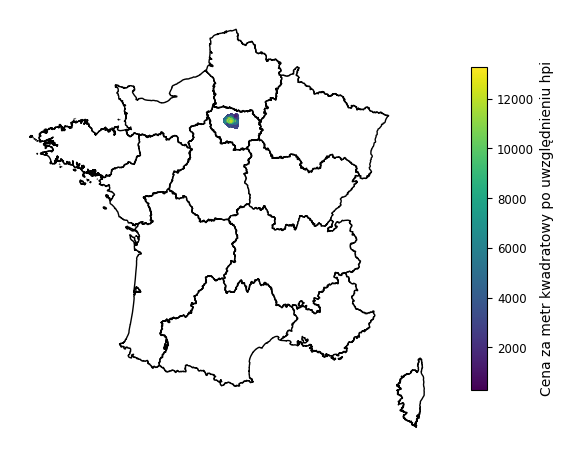

In [54]:
map = gpd.read_file(france_regions_map_url)

points = gpd.GeoDataFrame(sample,geometry=gpd.points_from_xy(sample.longitude, sample.latitude),crs="EPSG:4326")

low = points["price_m_2"].quantile(0.05)
high = points["price_m_2"].quantile(0.95)

points = points[(points["price_m_2"] >= 0) & (points["price_m_2"] <= high)]

fig, ax = plt.subplots(figsize=(7, 7))
map.plot(ax=ax, facecolor="white", edgecolor="black")
points.plot(ax=ax, column="price_m_2", cmap="viridis", markersize= 3, alpha=0.8, legend=True, legend_kwds={"shrink": 0.6, "label": "Cena za metr kwadratowy po uwzględnieniu hpi"})

ax.set_axis_off()
plt.show()

In [ ]:

map = gpd.read_file(france_regions_map_url)

points = gpd.GeoDataFrame(sample,geometry=gpd.points_from_xy(sample.longitude, sample.latitude),crs="EPSG:4326")

low = points["price_m_2"].quantile(0.02)
high = points["price_m_2"].quantile(0.98)
points = points[(points["price_m_2"] >= low) & (points["price_m_2"] <= high)]


fig, ax = plt.subplots(figsize=(7, 7))
map.plot(ax=ax, facecolor="white", edgecolor="black")
norm = colors.LogNorm(vmin=points["price_m_2"].min(), vmax=points["price_m_2"].max())
points.plot(ax=ax, column="price_m_2", cmap="viridis", markersize=5, alpha=0.8, legend=True, norm=norm, legend_kwds={"shrink": 0.6, "label": "Cena za m² (skala log)"})

ax.set_axis_off()
plt.show()

C:\Users\jpiec\AppData\Local\Temp\ipykernel_25620\2272341967.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [62]:
# PRZYKŁAD: zależność ceny za metr kwadratowy od lokalizacji w rejonie paryskim #
sample_paris = sample.sample(30000)

points_paris = gpd.GeoDataFrame(sample_paris, geometry=gpd.points_from_xy(sample_paris.longitude, sample_paris.latitude), crs="EPSG:4326")

paris_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
paris_map = gpd.read_file(paris_url).to_crs("EPSG:4326")
paris_shape = paris_map[paris_map["code"] == "75056"]


center = [points_paris.geometry.y.mean(), points_paris.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

folium.GeoJson(paris_shape.__geo_interface__, name="Obrys Paryża", style_function=lambda x: {"color": "black", "weight": 2, "fillOpacity": 0}).add_to(m)

vmin = float(points_paris["price_m_2"].quantile(0.05))
vmax = float(points_paris["price_m_2"].quantile(0.95))

cmap = linear.YlOrRd_09.scale(vmin, vmax)
cmap.caption = "Cena / m² (adj)"


for r in points_paris.itertuples(index=False):
    val = float(r.price_m_2)
    col = cmap(val)

    folium.CircleMarker(location=[r.latitude, r.longitude], radius=3, color=col, fill=True, fill_color=col, fill_opacity=0.75, weight=0).add_to(m)

cmap.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

out_html = "paris_prices.html"
m.save(out_html)


In [63]:
sample.to_csv(f'D:\\nieruchomosci_ostateczne\\samples\\sample_final\\{key}.txt')